# Modeling Approach

Based on the EDA, bike rental demand appears to be influenced by temporal, seasonal and weather-related factors. Therefore, several regression models are trained and compared.

The selected models cover different levels of complexity:

1. Dummy Regressor as baseline
2. Linear Regression as interpretable benchmark
3. Ridge Regression to address multicollinearity and regularization
4. Random Forest Regressor to capture non-linear relationships
5. HistGradientBoostingRegressor to model complex interactions more effectively

All models are evaluated using MAE, RMSE and R².

## General Notes
### Excluded Columns

Before training the models, some columns are excluded from the feature set. This is necessary to avoid misleading results and to ensure that the models learn meaningful relationships from the data.

#### Target Variable

The column `cnt` is excluded from the input features because it is the target variable that should be predicted.

Including `cnt` as an input feature would make the prediction task invalid, since the model would already have access to the value it is supposed to predict.

---

#### Leakage Features

The columns `casual` and `registered` are also excluded from the feature set.

These two variables represent the number of casual and registered users, and together they directly form the target variable:

`cnt = casual + registered`

If these columns were included, the model would receive direct information about the target variable. This would lead to data leakage and artificially high model performance. In practice, such a model would not be useful because these values would usually not be known before predicting total demand.

---

#### Identifier Column

The column `instant` is removed because it only represents a sequential identifier for each observation.

It does not contain meaningful information about bike rental demand and could introduce artificial patterns into the model.

---

#### Date Column

The column `dteday` is not used directly as a model feature because it is stored as a date value and cannot be interpreted meaningfully by most machine learning models in its raw form.

The raw date column is excluded because relevant temporal information is already available through variables such as `yr`, `mnth`, `weekday`, and `hr`. Additional date-based features can be derived separately if needed.

---

#### Summary

The following columns are excluded before model training:

- `cnt`: target variable
- `casual`: leakage feature
- `registered`: leakage feature
- `instant`: non-informative identifier
- `dteday`: raw date column, already represented by derived temporal features

This ensures that the models are trained only on features that would realistically be available before making a prediction.

## Feature Engineering
In this section, the original dataset is transformed into a model-ready feature set.

The goal of feature engineering is to create additional variables that better represent the patterns observed during the exploratory data analysis. In particular, the EDA indicated that bike rental demand is strongly influenced by temporal structures, commuting behavior, seasonal effects, and weather-related conditions.

Therefore, new features are derived from existing variables, including date-based features, cyclical time encodings, interaction features, rush-hour indicators, daytime categories, and weekend indicators.

At the same time, invalid or non-informative columns are removed from the feature set. This includes the target variable, leakage features, identifiers, and the raw date column.

The resulting feature matrix serves as the basis for the following preprocessing and model training steps.

### Imports

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("./hour.csv")

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Create Working Copy

A copy of the original dataset is created to avoid modifying the raw data directly.

In [5]:
df_fe = df.copy() # fe for feature engineering

df_fe.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Convert Date Column

In [6]:
df_fe["dteday"] = pd.to_datetime(df_fe["dteday"])

df_fe = df_fe.sort_values(["dteday", "hr"]).reset_index(drop=True)

df_fe["dteday"].head()

0   2011-01-01
1   2011-01-01
2   2011-01-01
3   2011-01-01
4   2011-01-01
Name: dteday, dtype: datetime64[ns]

### Create Additional Date-Based Features

Additional date-based features are extracted from `dteday`.

These features may help models capture calendar-related effects more explicitly.

In [7]:
df_fe["day"] = df_fe["dteday"].dt.day
df_fe["dayofyear"] = df_fe["dteday"].dt.dayofyear

# Custom week of year based on dayofyear
# This avoids ISO calendar behavior where early January dates can belong to the last week of the previous year.
df_fe["weekofyear"] = ((df_fe["dayofyear"] - 1) // 7 + 1).astype(int)

df_fe[["dteday", "day", "dayofyear", "weekofyear"]].head()

,dteday,day,dayofyear,weekofyear
0,2011-01-01,1,1,1
1,2011-01-01,1,1,1
2,2011-01-01,1,1,1
3,2011-01-01,1,1,1
4,2011-01-01,1,1,1


### Create Cyclical Time Features

Some temporal variables are cyclical.  
For example, hour 23 and hour 0 are close in reality, although they are numerically far apart.

To represent this structure better, sine and cosine transformations are created for:

- hour of day
- weekday
- month

These features are especially useful for linear models.

In [8]:
# Hour: 0–23
df_fe["hr_sin"] = np.sin(2 * np.pi * df_fe["hr"] / 24)
df_fe["hr_cos"] = np.cos(2 * np.pi * df_fe["hr"] / 24)

# Weekday: 0–6
df_fe["weekday_sin"] = np.sin(2 * np.pi * df_fe["weekday"] / 7)
df_fe["weekday_cos"] = np.cos(2 * np.pi * df_fe["weekday"] / 7)

# Month: 1–12
df_fe["mnth_sin"] = np.sin(2 * np.pi * df_fe["mnth"] / 12)
df_fe["mnth_cos"] = np.cos(2 * np.pi * df_fe["mnth"] / 12)

df_fe[
    [
        "hr", "hr_sin", "hr_cos",
        "weekday", "weekday_sin", "weekday_cos",
        "mnth", "mnth_sin", "mnth_cos"
    ]
].head()

,hr,hr_sin,hr_cos,weekday,weekday_sin,weekday_cos,mnth,mnth_sin,mnth_cos
0,0,0.000000,1.000000,6,-0.781831,0.62349,1,0.5,0.866025
1,1,0.258819,0.965926,6,-0.781831,0.62349,1,0.5,0.866025
2,2,0.500000,0.866025,6,-0.781831,0.62349,1,0.5,0.866025
3,3,0.707107,0.707107,6,-0.781831,0.62349,1,0.5,0.866025
4,4,0.866025,0.500000,6,-0.781831,0.62349,1,0.5,0.866025


### Create Interaction Features

The EDA showed that the effect of some variables may depend on other variables.

For example, the impact of temperature may differ between seasons, and environmental conditions such as humidity or wind may interact with weather categories.

Therefore, selected interaction features are created.

In [9]:
df_fe["temp_x_season"] = df_fe["temp"] * df_fe["season"]
df_fe["temp_x_workingday"] = df_fe["temp"] * df_fe["workingday"]
df_fe["hum_x_weathersit"] = df_fe["hum"] * df_fe["weathersit"]
df_fe["windspeed_x_weathersit"] = df_fe["windspeed"] * df_fe["weathersit"]

df_fe[
    [
        "temp", "season", "temp_x_season",
        "workingday", "temp_x_workingday",
        "hum", "weathersit", "hum_x_weathersit",
        "windspeed", "windspeed_x_weathersit"
    ]
].head()

,temp,season,temp_x_season,workingday,temp_x_workingday,hum,weathersit,hum_x_weathersit,windspeed,windspeed_x_weathersit
0,0.24,1,0.24,0,0.0,0.81,1,0.81,0.0,0.0
1,0.22,1,0.22,0,0.0,0.80,1,0.80,0.0,0.0
2,0.22,1,0.22,0,0.0,0.80,1,0.80,0.0,0.0
3,0.24,1,0.24,0,0.0,0.75,1,0.75,0.0,0.0
4,0.24,1,0.24,0,0.0,0.75,1,0.75,0.0,0.0


### Create Rush Hour Feature

The EDA showed clear demand peaks during typical commuting hours.

A binary feature is created to indicate whether an observation belongs to a rush hour period.

In [10]:
df_fe["rush_hour"] = df_fe["hr"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

df_fe[["hr", "rush_hour"]].head(12)

,hr,rush_hour
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,0
6,6,0
7,7,1
8,8,1
9,9,1


### Create Daytime Category

The hour of the day is grouped into broader time periods.

This feature may help models capture general daily usage phases such as morning, afternoon, evening, and night.

In [11]:
def get_daytime(hour):
    if 5 <= hour < 12:
        return "morning"
    elif 12 <= hour < 17:
        return "afternoon"
    elif 17 <= hour < 21:
        return "evening"
    else:
        return "night"


df_fe["daytime"] = df_fe["hr"].apply(get_daytime)

df_fe[["hr", "daytime"]].head(24)

,hr,daytime
0,0,night
1,1,night
2,2,night
3,3,night
4,4,night
5,5,morning
6,6,morning
7,7,morning
8,8,morning
9,9,morning


### Create Weekend Feature

A binary weekend feature is created based on the weekday variable.

This provides an additional distinction between regular weekdays and weekends.

In [12]:
df_fe["is_weekend"] = df_fe["weekday"].isin([0, 6]).astype(int)

df_fe[["weekday", "is_weekend"]].drop_duplicates().sort_values("weekday")

,weekday,is_weekend
24,0,1
47,1,0
69,2,0
92,3,0
115,4,0
138,5,0
0,6,1


## Lag Features

Since the dataset contains hourly observations, previous demand values can provide useful information for predicting current bike rental demand.

Lag features are created based on the target variable `cnt`. They represent demand in previous time steps, such as the previous hour, the same hour on the previous day, or the same hour in the previous week.

Only past values are used to avoid target leakage.

In [13]:
# Lag features based on previous demand
df_fe["cnt_lag_1"] = df_fe["cnt"].shift(1)
df_fe["cnt_lag_2"] = df_fe["cnt"].shift(2)
df_fe["cnt_lag_24"] = df_fe["cnt"].shift(24)
df_fe["cnt_lag_48"] = df_fe["cnt"].shift(48)
df_fe["cnt_lag_168"] = df_fe["cnt"].shift(168)

df_fe[
    [
        "dteday", "hr", "cnt",
        "cnt_lag_1", "cnt_lag_2",
        "cnt_lag_24", "cnt_lag_48", "cnt_lag_168"
    ]
].head(30)

,dteday,hr,cnt,cnt_lag_1,cnt_lag_2,cnt_lag_24,cnt_lag_48,cnt_lag_168
0,2011-01-01,0,16,NaN,NaN,NaN,NaN,NaN
1,2011-01-01,1,40,16.0,NaN,NaN,NaN,NaN
2,2011-01-01,2,32,40.0,16.0,NaN,NaN,NaN
3,2011-01-01,3,13,32.0,40.0,NaN,NaN,NaN
4,2011-01-01,4,1,13.0,32.0,NaN,NaN,NaN
5,2011-01-01,5,1,1.0,13.0,NaN,NaN,NaN
6,2011-01-01,6,2,1.0,1.0,NaN,NaN,NaN
7,2011-01-01,7,3,2.0,1.0,NaN,NaN,NaN
8,2011-01-01,8,8,3.0,2.0,NaN,NaN,NaN
9,2011-01-01,9,14,8.0,3.0,NaN,NaN,NaN


### Rolling Window Features

Rolling window features summarize recent demand patterns over a defined time window.

To avoid target leakage, the target variable is shifted before applying rolling calculations. This ensures that the current value of `cnt` is not included in the rolling statistics used to predict itself.

In [14]:
# Rolling features based only on past demand
df_fe["cnt_roll_3_mean"] = df_fe["cnt"].shift(1).rolling(window=3).mean()
df_fe["cnt_roll_6_mean"] = df_fe["cnt"].shift(1).rolling(window=6).mean()
df_fe["cnt_roll_24_mean"] = df_fe["cnt"].shift(1).rolling(window=24).mean()
df_fe["cnt_roll_24_std"] = df_fe["cnt"].shift(1).rolling(window=24).std()

df_fe[
    [
        "dteday", "hr", "cnt",
        "cnt_roll_3_mean",
        "cnt_roll_6_mean",
        "cnt_roll_24_mean",
        "cnt_roll_24_std"
    ]
].head(30)

,dteday,hr,cnt,cnt_roll_3_mean,cnt_roll_6_mean,cnt_roll_24_mean,cnt_roll_24_std
0,2011-01-01,0,16,NaN,NaN,NaN,NaN
1,2011-01-01,1,40,NaN,NaN,NaN,NaN
2,2011-01-01,2,32,NaN,NaN,NaN,NaN
3,2011-01-01,3,13,29.333333,NaN,NaN,NaN
4,2011-01-01,4,1,28.333333,NaN,NaN,NaN
5,2011-01-01,5,1,15.333333,NaN,NaN,NaN
6,2011-01-01,6,2,5.000000,17.166667,NaN,NaN
7,2011-01-01,7,3,1.333333,14.833333,NaN,NaN
8,2011-01-01,8,8,2.000000,8.666667,NaN,NaN
9,2011-01-01,9,14,4.333333,4.666667,NaN,NaN


### Remove Rows with Missing Lag and Rolling Features

Lag and rolling features create missing values at the beginning of the dataset because no sufficient historical information is available for the first observations.

These rows are removed before model training.

In [15]:
df_fe = df_fe.dropna().reset_index(drop=True)

df_fe.isna().sum().sum()

np.int64(0)

### Define Target Variable

The target variable is `cnt`, representing the total number of bike rentals per hour.

In [16]:
y = df_fe["cnt"]

y.head()

0     9
1    15
2    20
3    61
4    62
Name: cnt, dtype: int64

### Remove Excluded Columns

Several columns are excluded before model training:

- `cnt`: target variable
- `casual`: leakage feature
- `registered`: leakage feature
- `instant`: non-informative identifier
- `dteday`: raw date column

This prevents target leakage and ensures that only meaningful predictor variables are used.

In [17]:
columns_to_drop = [
    "cnt",
    "casual",
    "registered",
    "instant",
    "dteday"
]

X = df_fe.drop(columns=columns_to_drop)

X.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,is_weekend,cnt_lag_1,cnt_lag_2,cnt_lag_24,cnt_lag_48,cnt_lag_168,cnt_roll_3_mean,cnt_roll_6_mean,cnt_roll_24_mean,cnt_roll_24_std
0,1,0,1,7,0,6,0,2,0.16,0.1818,...,1,2.0,5.0,84.0,36.0,16.0,2.666667,7.833333,63.208333,55.844488
1,1,0,1,8,0,6,0,3,0.16,0.1818,...,1,9.0,2.0,210.0,95.0,40.0,5.333333,6.666667,60.083333,56.721989
2,1,0,1,9,0,6,0,3,0.16,0.1818,...,1,15.0,9.0,134.0,219.0,32.0,8.666667,6.500000,51.958333,47.536237
3,1,0,1,10,0,6,0,2,0.18,0.1970,...,1,20.0,15.0,63.0,122.0,13.0,14.666667,8.666667,47.208333,44.585998
4,1,0,1,11,0,6,0,2,0.20,0.1818,...,1,61.0,20.0,67.0,45.0,1.0,32.000000,18.666667,47.125000,44.557059


### Check Final Feature Matrix

The final feature matrix is checked before preprocessing and model training.

In [18]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()
X.dtypes

Feature matrix shape: (17211, 37)
Target shape: (17211,)


season                      int64
yr                          int64
mnth                        int64
hr                          int64
holiday                     int64
weekday                     int64
workingday                  int64
weathersit                  int64
temp                      float64
atemp                     float64
hum                       float64
windspeed                 float64
day                         int32
dayofyear                   int32
weekofyear                  int64
hr_sin                    float64
hr_cos                    float64
weekday_sin               float64
weekday_cos               float64
mnth_sin                  float64
mnth_cos                  float64
temp_x_season             float64
temp_x_workingday         float64
hum_x_weathersit          float64
windspeed_x_weathersit    float64
rush_hour                   int64
daytime                    object
is_weekend                  int64
cnt_lag_1                 float64
cnt_lag_2     

### Identify Categorical, Binary and Numerical Features

For later preprocessing, the features are separated into categorical, binary, and numerical variables.

This is necessary because different feature types require different preprocessing steps.

In [19]:
categorical_features = [
    "season",
    "mnth",
    "hr",
    "weekday",
    "weathersit",
    "daytime"
]

binary_features = [
    "yr",
    "holiday",
    "workingday",
    "rush_hour",
    "is_weekend"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features + binary_features
]

print("Categorical features:")
print(categorical_features)

print("\nBinary features:")
print(binary_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['season', 'mnth', 'hr', 'weekday', 'weathersit', 'daytime']

Binary features:
['yr', 'holiday', 'workingday', 'rush_hour', 'is_weekend']

Numerical features:
['temp', 'atemp', 'hum', 'windspeed', 'day', 'dayofyear', 'weekofyear', 'hr_sin', 'hr_cos', 'weekday_sin', 'weekday_cos', 'mnth_sin', 'mnth_cos', 'temp_x_season', 'temp_x_workingday', 'hum_x_weathersit', 'windspeed_x_weathersit', 'cnt_lag_1', 'cnt_lag_2', 'cnt_lag_24', 'cnt_lag_48', 'cnt_lag_168', 'cnt_roll_3_mean', 'cnt_roll_6_mean', 'cnt_roll_24_mean', 'cnt_roll_24_std']


### Validate Feature Groups

Before continuing, the feature groups are checked to ensure that every feature is assigned to exactly one group.

In [20]:
all_grouped_features = categorical_features + binary_features + numerical_features

print("Number of columns in X:", len(X.columns))
print("Number of grouped features:", len(all_grouped_features))

missing_features = set(X.columns) - set(all_grouped_features)
extra_features = set(all_grouped_features) - set(X.columns)
duplicate_count = len(all_grouped_features) - len(set(all_grouped_features))

print("Missing features:", missing_features)
print("Extra features:", extra_features)
print("Number of duplicate assignments:", duplicate_count)

Number of columns in X: 37
Number of grouped features: 37
Missing features: set()
Extra features: set()
Number of duplicate assignments: 0


### Feature Engineering Summary

The feature engineering process created additional variables based on temporal and environmental patterns observed during the EDA.

The following feature types were added:

- Date-based features such as day, day of year, and calendar week
- Cyclical encodings for hour, weekday, and month
- Interaction features between weather, season, and working day variables
- A rush hour indicator based on commuting peaks
- A daytime category
- A weekend indicator

Leakage features and non-informative columns were removed before modeling.

The resulting feature matrix can now be used for preprocessing pipelines and model training.

## Preprocessing
In this section, the prepared feature matrix is split into training and test data.  
Afterwards, separate preprocessing strategies are defined for different model types.

The preprocessing is designed to avoid data leakage by fitting transformations only on the training data.

### Check Feature Matrix and Target Variable

Before splitting the data, the feature matrix `X` and target variable `y` are checked.

In [21]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Feature matrix shape: (17211, 37)
Target shape: (17211,)


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,is_weekend,cnt_lag_1,cnt_lag_2,cnt_lag_24,cnt_lag_48,cnt_lag_168,cnt_roll_3_mean,cnt_roll_6_mean,cnt_roll_24_mean,cnt_roll_24_std
0,1,0,1,7,0,6,0,2,0.16,0.1818,...,1,2.0,5.0,84.0,36.0,16.0,2.666667,7.833333,63.208333,55.844488
1,1,0,1,8,0,6,0,3,0.16,0.1818,...,1,9.0,2.0,210.0,95.0,40.0,5.333333,6.666667,60.083333,56.721989
2,1,0,1,9,0,6,0,3,0.16,0.1818,...,1,15.0,9.0,134.0,219.0,32.0,8.666667,6.500000,51.958333,47.536237
3,1,0,1,10,0,6,0,2,0.18,0.1970,...,1,20.0,15.0,63.0,122.0,13.0,14.666667,8.666667,47.208333,44.585998
4,1,0,1,11,0,6,0,2,0.20,0.1818,...,1,61.0,20.0,67.0,45.0,1.0,32.000000,18.666667,47.125000,44.557059


0     9
1    15
2    20
3    61
4    62
Name: cnt, dtype: int64

### Define Feature Groups

The features are grouped into categorical, binary, and numerical variables.

This is necessary because different feature types require different preprocessing steps:

- categorical features are one-hot encoded
- binary features are passed through unchanged
- numerical features are scaled for linear models but not for tree-based models

In [22]:
categorical_features = [
    "season",
    "mnth",
    "hr",
    "weekday",
    "weathersit",
    "daytime"
]

binary_features = [
    "yr",
    "holiday",
    "workingday",
    "rush_hour",
    "is_weekend"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features + binary_features
]

print("Categorical features:")
print(categorical_features)

print("\nBinary features:")
print(binary_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['season', 'mnth', 'hr', 'weekday', 'weathersit', 'daytime']

Binary features:
['yr', 'holiday', 'workingday', 'rush_hour', 'is_weekend']

Numerical features:
['temp', 'atemp', 'hum', 'windspeed', 'day', 'dayofyear', 'weekofyear', 'hr_sin', 'hr_cos', 'weekday_sin', 'weekday_cos', 'mnth_sin', 'mnth_cos', 'temp_x_season', 'temp_x_workingday', 'hum_x_weathersit', 'windspeed_x_weathersit', 'cnt_lag_1', 'cnt_lag_2', 'cnt_lag_24', 'cnt_lag_48', 'cnt_lag_168', 'cnt_roll_3_mean', 'cnt_roll_6_mean', 'cnt_roll_24_mean', 'cnt_roll_24_std']


In [23]:
all_grouped_features = categorical_features + binary_features + numerical_features

missing_features = set(X.columns) - set(all_grouped_features)
extra_features = set(all_grouped_features) - set(X.columns)
duplicate_count = len(all_grouped_features) - len(set(all_grouped_features))

print("Number of columns in X:", len(X.columns))
print("Number of grouped features:", len(all_grouped_features))

print("\nMissing features:", missing_features)
print("Extra features:", extra_features)
print("Number of duplicate assignments:", duplicate_count)

Number of columns in X: 37
Number of grouped features: 37

Missing features: set()
Extra features: set()
Number of duplicate assignments: 0


### Chronological Train-Test Split

A chronological train-test split is used because the observations are time-dependent.

The first 80% of the observations are used for training, while the last 20% are kept as a final holdout test set.

This reflects a realistic forecasting scenario where future demand is predicted based on past observations.

In [24]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (13768, 37)
X_test shape: (3443, 37)
y_train shape: (13768,)
y_test shape: (3443,)


### Check Train-Test Split

The split is checked to make sure that the training and test sets are separated correctly.

In [25]:
print("Training set:")
print("Start index:", X_train.index.min())
print("End index:", X_train.index.max())

print("\nTest set:")
print("Start index:", X_test.index.min())
print("End index:", X_test.index.max())

Training set:
Start index: 0
End index: 13767

Test set:
Start index: 13768
End index: 17210


### Time-Series Cross-Validation

Instead of standard k-fold cross-validation, `TimeSeriesSplit` is used.

This ensures that, in each validation fold, the training data always comes before the validation data. This avoids leakage from future observations into the training process.

The final test set remains untouched and is only used for the final evaluation.

In [26]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    print(f"Fold {fold}")
    print("Train indices:", train_idx[0], "to", train_idx[-1])
    print("Validation indices:", val_idx[0], "to", val_idx[-1])
    print("Train size:", len(train_idx))
    print("Validation size:", len(val_idx))
    print()

Fold 1
Train indices: 0 to 2297
Validation indices: 2298 to 4591
Train size: 2298
Validation size: 2294

Fold 2
Train indices: 0 to 4591
Validation indices: 4592 to 6885
Train size: 4592
Validation size: 2294

Fold 3
Train indices: 0 to 6885
Validation indices: 6886 to 9179
Train size: 6886
Validation size: 2294

Fold 4
Train indices: 0 to 9179
Validation indices: 9180 to 11473
Train size: 9180
Validation size: 2294

Fold 5
Train indices: 0 to 11473
Validation indices: 11474 to 13767
Train size: 11474
Validation size: 2294



In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Preprocessor for Linear Models

Linear models require numerical variables to be on a comparable scale and cannot directly process categorical variables.

Therefore, the preprocessing for linear models includes:

- one-hot encoding for categorical variables
- standard scaling for numerical variables
- passing binary variables through unchanged

This preprocessor will later be used for Linear Regression and Ridge Regression.

In [28]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    remainder="drop"
)

linear_preprocessor

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['season', 'mnth', 'hr', 'weekday',
                                  'weathersit', 'daytime']),
                                ('numerical', StandardScaler(),
                                 ['temp', 'atemp', 'hum', 'windspeed', 'day',
                                  'dayofyear', 'weekofyear', 'hr_sin', 'hr_cos',
                                  'weekday_sin', 'weekday_cos', 'mnth_sin',
                                  'mnth_cos', 'temp_x_season',
                                  'temp_x_workingday', 'hum_x_weathersit',
                                  'windspeed_x_weathersit', 'cnt_lag_1',
                                  'cnt_lag_2', 'cnt_lag_24', 'cnt_lag_48',
                                  'cnt_lag_168', 'cnt_roll_3_mean',
                                  'cnt_roll_6_mean', 'cnt_roll_24_mean',
                                  'cnt_roll_24_std']),
                                ('binary', 'passthrough',
                                 ['yr', 'holiday', 'workingday', 'rush_hour',
                                  'is_weekend'])])

### Preprocessor for Tree-Based Models

Tree-based models do not require feature scaling because they split features based on thresholds.

However, categorical variables are still one-hot encoded to avoid treating category labels as meaningful numerical orders.

Therefore, the preprocessing for tree-based models includes:

- one-hot encoding for categorical variables
- passing numerical variables through unchanged
- passing binary variables through unchanged

This preprocessor will later be used for Random Forest and HistGradientBoostingRegressor.

In [29]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    remainder="drop"
)

tree_preprocessor

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['season', 'mnth', 'hr', 'weekday',
                                  'weathersit', 'daytime']),
                                ('numerical', 'passthrough',
                                 ['temp', 'atemp', 'hum', 'windspeed', 'day',
                                  'dayofyear', 'weekofyear', 'hr_sin', 'hr_cos',
                                  'weekday_sin', 'weekday_cos', 'mnth_sin',
                                  'mnth_cos', 'temp_x_season',
                                  'temp_x_workingday', 'hum_x_weathersit',
                                  'windspeed_x_weathersit', 'cnt_lag_1',
                                  'cnt_lag_2', 'cnt_lag_24', 'cnt_lag_48',
                                  'cnt_lag_168', 'cnt_roll_3_mean',
                                  'cnt_roll_6_mean', 'cnt_roll_24_mean',
                                  'cnt_roll_24_std']),
                                ('binary', 'passthrough',
                                 ['yr', 'holiday', 'workingday', 'rush_hour',
                                  'is_weekend'])])

### Test Preprocessing Output

The preprocessors are applied once to the training data to verify that the transformations work correctly.

In the actual modeling step, the preprocessors will be used inside full model pipelines.

In [30]:
X_train_linear_processed = linear_preprocessor.fit_transform(X_train)
X_train_tree_processed = tree_preprocessor.fit_transform(X_train)

print("Linear preprocessing output shape:", X_train_linear_processed.shape)
print("Tree preprocessing output shape:", X_train_tree_processed.shape)

Linear preprocessing output shape: (13768, 80)
Tree preprocessing output shape: (13768, 80)


### Extract Transformed Feature Names

After one-hot encoding, categorical variables are expanded into multiple columns.

Extracting the transformed feature names is useful for later model interpretation, especially for coefficients and feature importance.

In [31]:
linear_feature_names = linear_preprocessor.get_feature_names_out()
tree_feature_names = tree_preprocessor.get_feature_names_out()

print("Number of linear model features:", len(linear_feature_names))
print("Number of tree-based model features:", len(tree_feature_names))

linear_feature_names[:20]

Number of linear model features: 80
Number of tree-based model features: 80


array(['categorical__season_2', 'categorical__season_3',
       'categorical__season_4', 'categorical__mnth_2',
       'categorical__mnth_3', 'categorical__mnth_4',
       'categorical__mnth_5', 'categorical__mnth_6',
       'categorical__mnth_7', 'categorical__mnth_8',
       'categorical__mnth_9', 'categorical__mnth_10',
       'categorical__mnth_11', 'categorical__mnth_12',
       'categorical__hr_1', 'categorical__hr_2', 'categorical__hr_3',
       'categorical__hr_4', 'categorical__hr_5', 'categorical__hr_6'],
      dtype=object)

### Preprocessing Summary

The preprocessing step prepared the data for model training while preserving the temporal structure of the dataset.

A chronological holdout split was used to create a final test set.  
Additionally, `TimeSeriesSplit` was defined for cross-validation on the training data.

Two preprocessing strategies were created:

1. **Linear model preprocessing**
   - one-hot encoding for categorical features
   - scaling of numerical features
   - binary features passed through unchanged

2. **Tree-based model preprocessing**
   - one-hot encoding for categorical features
   - numerical and binary features passed through unchanged

These preprocessing objects can now be combined with different regression models in scikit-learn pipelines.

## Model Training
In this section, several regression models are trained and compared.

The selected models represent different levels of complexity:

1. Dummy Regressor as baseline model
2. Linear Regression as an interpretable benchmark
3. Ridge Regression as a regularized linear model
4. Random Forest Regressor as a non-linear tree-based model
5. HistGradientBoostingRegressor as a more advanced boosting model

All models are evaluated using time-series cross-validation on the training set.  
Afterwards, the models are trained on the full training set and evaluated on the final holdout test set.

### Imports


In [32]:
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pandas as pd
import numpy as np

### Define Models

The models are defined as scikit-learn pipelines.

For linear models, the linear preprocessing pipeline is used.  
For tree-based models, the tree-based preprocessing pipeline is used.

In [33]:
models = {
    "Dummy Regressor": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", DummyRegressor(strategy="mean"))
        ]
    ),

    "Linear Regression": Pipeline(
        steps=[
            ("preprocessor", linear_preprocessor),
            ("model", LinearRegression())
        ]
    ),

    "Ridge Regression": Pipeline(
        steps=[
            ("preprocessor", linear_preprocessor),
            ("model", Ridge(alpha=1.0))
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),

    "Hist Gradient Boosting": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", HistGradientBoostingRegressor(
                max_iter=300,
                learning_rate=0.05,
                random_state=42
            ))
        ]
    )
}

models

{'Dummy Regressor': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('categorical',
                                                   OneHotEncoder(drop='first',
                                                                 handle_unknown='ignore',
                                                                 sparse_output=False),
                                                   ['season', 'mnth', 'hr',
                                                    'weekday', 'weathersit',
                                                    'daytime']),
                                                  ('numerical', 'passthrough',
                                                   ['temp', 'atemp', 'hum',
                                                    'windspeed', 'day',
                                                    'dayofyear', 'weekofyear',
                                                    'hr_sin', 'hr_cos',
                             

### Cross-Validation Setup

The models are evaluated using `TimeSeriesSplit`.

The following metrics are used:

- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error
- R²: Explained variance

MAE and RMSE are easier to interpret because they are measured in the same unit as the target variable, namely bike rentals.

In [35]:
from sklearn.model_selection import cross_validate

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = []

for model_name, model in models.items():
    print(f"Evaluating: {model_name}")

    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results.append({
        "model": model_name,
        "MAE_mean": -scores["test_MAE"].mean(),
        "MAE_std": scores["test_MAE"].std(),
        "RMSE_mean": -scores["test_RMSE"].mean(),
        "RMSE_std": scores["test_RMSE"].std(),
        "R2_mean": scores["test_R2"].mean(),
        "R2_std": scores["test_R2"].std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values(by="RMSE_mean")

cv_results_df

Evaluating: Dummy Regressor
Evaluating: Linear Regression
Evaluating: Ridge Regression
Evaluating: Random Forest
Evaluating: Hist Gradient Boosting


,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
4,Hist Gradient Boosting,33.187780,9.635250,53.015563,15.462929,0.885760,0.065814
3,Random Forest,35.048991,9.682863,57.226863,14.993117,0.870190,0.058774
2,Ridge Regression,41.310653,7.245036,58.183288,8.864291,0.867313,0.034937
1,Linear Regression,41.554394,7.399949,58.375817,8.928332,0.866103,0.036745
0,Dummy Regressor,138.985364,31.216970,180.994842,43.723017,-0.212056,0.180768


### Cross-Validation Results

The cross-validation results provide an initial comparison of model performance on temporally ordered validation folds.

The model with the lowest RMSE and MAE performs best during cross-validation. However, the final model selection should not be based on cross-validation alone. The final holdout test set is used afterwards to estimate performance on unseen future data.

In [36]:
cv_results_df.sort_values(by="RMSE_mean")

,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
4,Hist Gradient Boosting,33.187780,9.635250,53.015563,15.462929,0.885760,0.065814
3,Random Forest,35.048991,9.682863,57.226863,14.993117,0.870190,0.058774
2,Ridge Regression,41.310653,7.245036,58.183288,8.864291,0.867313,0.034937
1,Linear Regression,41.554394,7.399949,58.375817,8.928332,0.866103,0.036745
0,Dummy Regressor,138.985364,31.216970,180.994842,43.723017,-0.212056,0.180768


### Visualization of Cross-Validation Performance

The cross-validation results are visualized to compare model performance more clearly.

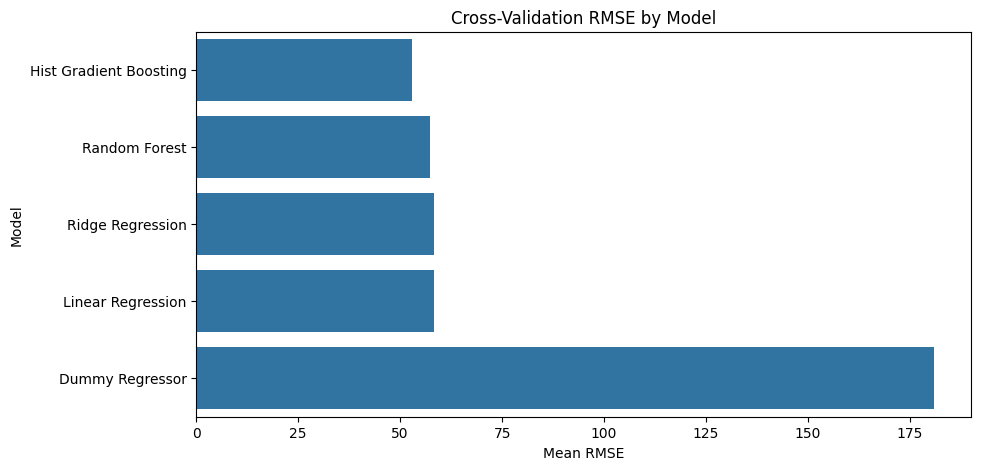

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=cv_results_df, x="RMSE_mean", y="model")
plt.title("Cross-Validation RMSE by Model")
plt.xlabel("Mean RMSE")
plt.ylabel("Model")
plt.show()

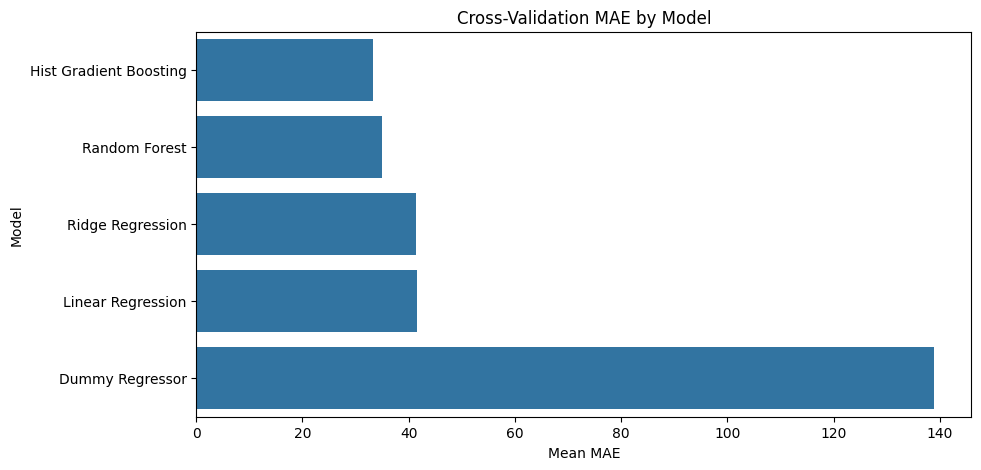

In [38]:
plt.figure(figsize=(10, 5))
sns.barplot(data=cv_results_df, x="MAE_mean", y="model")
plt.title("Cross-Validation MAE by Model")
plt.xlabel("Mean MAE")
plt.ylabel("Model")
plt.show()

### Interpretation

The cross-validation results show that all trained models clearly outperform the Dummy Regressor. This indicates that the selected features contain meaningful information for predicting bike rental demand.

The lowest MAE and RMSE values are achieved by the Hist Gradient Boosting model, followed closely by the Random Forest model. This suggests that non-linear tree-based models are better suited for this prediction task than purely linear approaches.

Linear Regression and Ridge Regression perform similarly, which indicates that regularization does not substantially improve the linear model in this setup. Both models are clearly better than the baseline but weaker than the tree-based models.

Overall, the results suggest that bike rental demand is influenced by non-linear relationships and interaction effects, which aligns with the patterns observed during the exploratory data analysis.

### Train Models on the Full Training Set

After cross-validation, all models are trained on the complete training set.

The final test set remains untouched during this step and is only used for the final evaluation.

In [39]:
trained_models = {}

for model_name, model in models.items():
    print(f"Training: {model_name}")
    model.fit(X_train, y_train)
    trained_models[model_name] = model

print("\nTraining completed.")

trained_models.keys()

Training: Dummy Regressor
Training: Linear Regression
Training: Ridge Regression
Training: Random Forest
Training: Hist Gradient Boosting

Training completed.


dict_keys(['Dummy Regressor', 'Linear Regression', 'Ridge Regression', 'Random Forest', 'Hist Gradient Boosting'])

## Evaluation

### Final Evaluation on Holdout Test Set

The trained models are evaluated on the final holdout test set.

This test set represents unseen future observations and is used to assess how well the models generalize beyond the training period.

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

test_results = []

for model_name, model in trained_models.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    test_results.append({
        "model": model_name,
        "Test_MAE": mae,
        "Test_RMSE": rmse,
        "Test_R2": r2
    })

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values(by="Test_RMSE")

test_results_df

,model,Test_MAE,Test_RMSE,Test_R2
4,Hist Gradient Boosting,29.219419,47.189135,0.953921
3,Random Forest,32.736889,56.052677,0.934985
2,Ridge Regression,47.413350,68.491620,0.902927
1,Linear Regression,47.583904,68.525511,0.902831
0,Dummy Regressor,174.214292,231.076477,-0.104931


### Comparison of Cross-Validation and Test Performance

The cross-validation results are compared with the final holdout test results.

This comparison helps assess whether model performance is stable or whether a model performs well during validation but poorly on unseen future data.

In [41]:
comparison_df = cv_results_df.merge(
    test_results_df,
    on="model",
    how="inner"
)

comparison_df = comparison_df[
    [
        "model",
        "MAE_mean",
        "Test_MAE",
        "RMSE_mean",
        "Test_RMSE",
        "R2_mean",
        "Test_R2"
    ]
]

comparison_df = comparison_df.rename(columns={
    "MAE_mean": "CV_MAE",
    "RMSE_mean": "CV_RMSE",
    "R2_mean": "CV_R2"
})

comparison_df.sort_values(by="Test_RMSE")

,model,CV_MAE,Test_MAE,CV_RMSE,Test_RMSE,CV_R2,Test_R2
0,Hist Gradient Boosting,33.187780,29.219419,53.015563,47.189135,0.885760,0.953921
1,Random Forest,35.048991,32.736889,57.226863,56.052677,0.870190,0.934985
2,Ridge Regression,41.310653,47.413350,58.183288,68.491620,0.867313,0.902927
3,Linear Regression,41.554394,47.583904,58.375817,68.525511,0.866103,0.902831
4,Dummy Regressor,138.985364,174.214292,180.994842,231.076477,-0.212056,-0.104931


### Best Model Selection

The best model is selected based on the lowest RMSE on the final holdout test set.

RMSE is used as the primary criterion because it penalizes large prediction errors more strongly, which is relevant for demand peaks in bike rental data.

In [42]:
best_model_name = test_results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

Best model: Hist Gradient Boosting


### Predictions of the Best Model

The predictions of the best-performing model are stored for further error analysis.

In [43]:
y_pred_best = best_model.predict(X_test)

prediction_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_best,
    "error": y_test.values - y_pred_best,
    "absolute_error": np.abs(y_test.values - y_pred_best)
})

prediction_df.head()

,actual,predicted,error,absolute_error
0,381,346.335411,34.664589,34.664589
1,233,295.844762,-62.844762,62.844762
2,136,153.739936,-17.739936,17.739936
3,67,67.697195,-0.697195,0.697195
4,28,28.645761,-0.645761,0.645761


### Error Analysis

The prediction errors are analyzed to understand where the model performs well and where it struggles.

This is especially important for demand forecasting because high-demand periods and peaks are often harder to predict.

In [44]:
prediction_df.describe()

,actual,predicted,error,absolute_error
count,3443.000000,3443.000000,3443.000000,3443.000000
mean,247.725821,245.210159,2.515661,29.219419
std,219.862588,208.010405,47.128877,37.059938
min,1.000000,0.329302,-339.703473,0.000392
25%,53.000000,61.488287,-14.653278,5.946889
50%,203.000000,205.823363,-0.075634,16.145763
75%,365.000000,373.284661,17.942082,38.160459
max,977.000000,888.934165,303.590526,339.703473


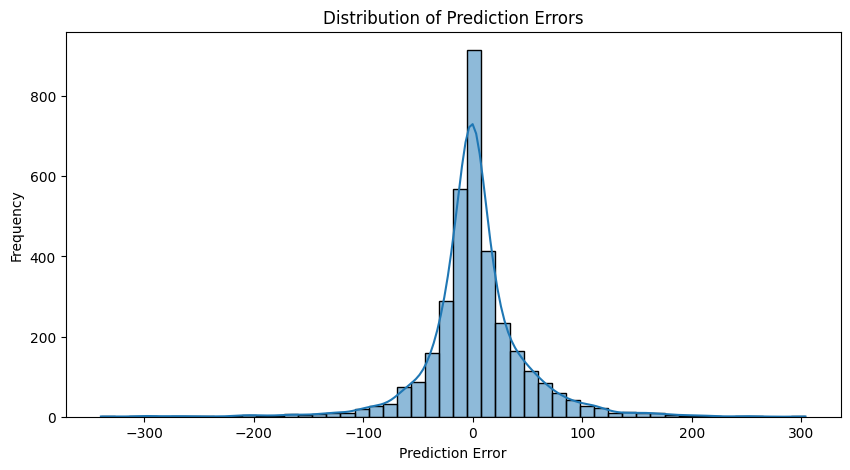

In [45]:
plt.figure(figsize=(10, 5))
sns.histplot(prediction_df["error"], bins=50, kde=True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

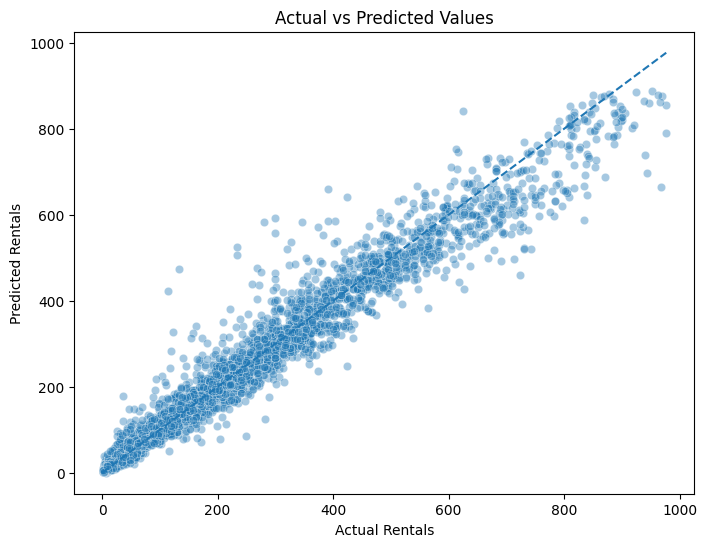

In [46]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=prediction_df, x="actual", y="predicted", alpha=0.4)
plt.plot(
    [prediction_df["actual"].min(), prediction_df["actual"].max()],
    [prediction_df["actual"].min(), prediction_df["actual"].max()],
    linestyle="--"
)
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")
plt.show()

### Interpretation

The final model selection identifies **Hist Gradient Boosting** as the best-performing model. This is consistent with the cross-validation results, where tree-based non-linear models performed better than the linear approaches.

The prediction error distribution is centered closely around zero, which indicates that the model does not show a strong systematic bias toward overprediction or underprediction. Most prediction errors are relatively small, while only a few larger errors occur at the tails of the distribution.

The actual-vs-predicted plot shows a strong positive alignment between true and predicted rental counts. Most observations are located close to the diagonal reference line, meaning that the model captures the general demand pattern well.

However, larger deviations are visible for high-demand observations. This suggests that peak demand situations are more difficult to predict accurately. In several cases, the model appears to underestimate very high rental counts, which is a common issue in demand forecasting because extreme peaks are less frequent and harder to learn.

Overall, the Hist Gradient Boosting model provides the strongest predictive performance among the tested models and captures the main temporal and weather-related demand patterns effectively. Nevertheless, the remaining errors indicate that further improvements could be achieved through additional tuning, more advanced lag features, or external data such as events or special holidays.

## Model Interpretation
After evaluating the models, the best-performing model is interpreted in more detail.

The goal of this section is to identify which features contribute most strongly to the prediction of bike rental demand.

Since the best-performing model is a pipeline including preprocessing and model estimation, permutation importance is used. This method is model-independent and measures how much model performance decreases when a feature is randomly shuffled.

### Permutation Importance

Permutation importance estimates the relevance of each feature by randomly shuffling one feature at a time and measuring the resulting decrease in model performance.

If shuffling a feature strongly worsens the model performance, the feature is considered important.

RMSE is used as the scoring metric because large prediction errors are especially relevant in demand forecasting.

In [47]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    estimator=best_model,
    X=X_test,
    y=y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

### Create Feature Importance DataFrame

The permutation importance results are converted into a DataFrame for easier interpretation.

In [48]:
perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

perm_importance_df = perm_importance_df.sort_values(
    by="importance_mean",
    ascending=False
)

perm_importance_df.head(20)

,feature,importance_mean,importance_std
28,cnt_lag_1,180.377326,2.204450
16,hr_cos,21.601614,0.525783
15,hr_sin,14.654452,0.573902
3,hr,13.771049,0.378191
30,cnt_lag_24,13.478246,0.628261
32,cnt_lag_168,11.462992,0.695584
22,temp_x_workingday,8.928341,0.629793
29,cnt_lag_2,5.757278,0.421060
23,hum_x_weathersit,3.108503,0.282913
36,cnt_roll_24_std,2.814089,0.286893


### Visualize Feature Importance

The most important features are visualized to identify the strongest predictors of bike rental demand.

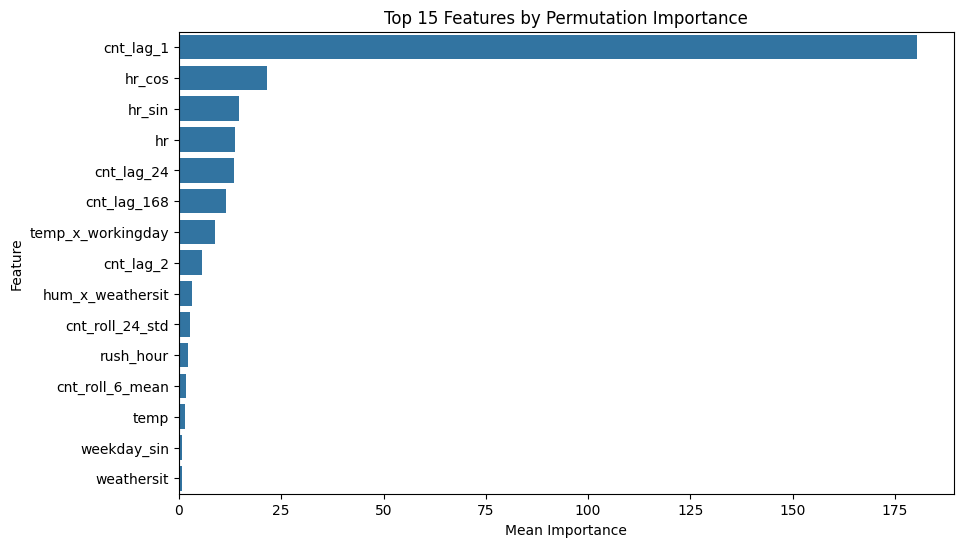

In [49]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=perm_importance_df.head(15),
    x="importance_mean",
    y="feature"
)

plt.title("Top 15 Features by Permutation Importance")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.show()

### Interpretation

The permutation importance results show that `cnt_lag_1` is by far the most important feature. This means that the bike rental demand of the previous hour is the strongest predictor for the current demand. The model therefore relies heavily on short-term temporal dependency.

Time-related features are also highly relevant. The features `hr_cos`, `hr_sin`, and `hr` indicate that the hour of the day strongly influences demand. This supports the EDA findings, where clear daily usage patterns and commuting peaks were observed.

Additional lag features such as `cnt_lag_24`, `cnt_lag_168`, and `cnt_lag_2` are also important. This suggests that demand is not only influenced by the previous hour, but also by recurring daily and weekly patterns.

The feature `temp_x_workingday` indicates that the effect of temperature differs depending on whether it is a working day. This supports the assumption that weather conditions and commuting behavior interact.

Weather-related features such as `hum_x_weathersit`, `temp`, and `weathersit` appear in the top 15, but their importance is clearly lower than the lag and time-based features. This suggests that weather contributes to the prediction, but historical demand and time structure are more dominant.

Overall, the model mainly predicts bike rental demand based on recent demand and temporal patterns. Weather-related variables provide additional information, but they are less influential than lag-based and time-based features.

## Hyperparameter Tuning

In this section, hyperparameter tuning is performed for the best-performing model from the previous evaluation.

The previous model comparison showed that Hist Gradient Boosting achieved the strongest predictive performance. Therefore, this model is selected for tuning.

To preserve the temporal structure of the data, the tuning process uses `TimeSeriesSplit` instead of standard k-fold cross-validation.

The final holdout test set is not used during tuning.

### Define Tuning Pipeline

The Hist Gradient Boosting model is combined with the tree-based preprocessing pipeline.

This ensures that the same preprocessing strategy used during model evaluation is also applied during hyperparameter tuning.

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

In [50]:
hgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", HistGradientBoostingRegressor(
            random_state=42,
            early_stopping=False
        ))
    ]
)

hgb_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['season', 'mnth', 'hr',
                                                   'weekday', 'weathersit',
                                                   'daytime']),
                                                 ('numerical', 'passthrough',
                                                  ['temp', 'atemp', 'hum',
                                                   'windspeed', 'day',
                                                   'dayofyear', 'weekofyear',
                                                   'hr_sin', 'hr_cos',
                                                   'weekday_sin', 'weekday_cos',
                                                   'mnt...
                                                   'temp_x_workingday',
                                                   'hum_x_weathersit',
                                                   'windspeed_x_weathersit',
                                                   'cnt_lag_1', 'cnt_lag_2',
                                                   'cnt_lag_24', 'cnt_lag_48',
                                                   'cnt_lag_168',
                                                   'cnt_roll_3_mean',
                                                   'cnt_roll_6_mean',
                                                   'cnt_roll_24_mean',
                                                   'cnt_roll_24_std']),
                                                 ('binary', 'passthrough',
                                                  ['yr', 'holiday',
                                                   'workingday', 'rush_hour',
                                                   'is_weekend'])])),
                ('model',
                 HistGradientBoostingRegressor(early_stopping=False,
                                               random_state=42))])

### Define Hyperparameter Grid

The following hyperparameters are tuned:

- `learning_rate`: controls how strongly each boosting iteration contributes
- `max_iter`: number of boosting iterations
- `max_leaf_nodes`: controls the complexity of individual trees
- `l2_regularization`: regularization strength to reduce overfitting
- `min_samples_leaf`: minimum number of samples required in each leaf

The goal is to find a configuration that improves predictive performance while avoiding overfitting.

In [52]:
param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__max_iter": [200, 300, 500],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__l2_regularization": [0.0, 0.1, 1.0],
    "model__min_samples_leaf": [20, 50]
}

### Run Grid Search with TimeSeriesSplit

The grid search evaluates different hyperparameter combinations using time-series cross-validation.

RMSE is used as the optimization criterion because larger prediction errors are especially relevant in demand forecasting.

In [53]:
grid_search = GridSearchCV(
    estimator=hgb_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('categorical',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['season',
                                                                          'mnth',
                                                                          'hr',
                                                                          'weekday',
                                                                          'weathersit',
                                                                          'daytime']),
                                                                        ('numerical',
                                                                         'passthrough',
                                                                         ['temp',
                                                                          'atemp',
                                                                          'hum...
                                                                          'is_weekend'])])),
                                       ('model',
                                        HistGradientBoostingRegressor(early_stopping=False,
                                                                      random_state=42))]),
             n_jobs=-1,
             param_grid={'model__l2_regularization': [0.0, 0.1, 1.0],
                         'model__learning_rate': [0.03, 0.05, 0.08],
                         'model__max_iter': [200, 300, 500],
                         'model__max_leaf_nodes': [15, 31, 63],
                         'model__min_samples_leaf': [20, 50]},
             scoring='neg_root_mean_squared_error', verbose=1)

### Best Hyperparameters

The best hyperparameter combination is extracted from the grid search results.

In [54]:
print("Best CV RMSE:", -grid_search.best_score_)
print("Best parameters:")
grid_search.best_params_

Best CV RMSE: 49.64519759004499
Best parameters:


{'model__l2_regularization': 0.0,
 'model__learning_rate': 0.05,
 'model__max_iter': 500,
 'model__max_leaf_nodes': 15,
 'model__min_samples_leaf': 20}

### Tuning Results Overview

The grid search results are converted into a DataFrame to compare the tested configurations.

In [55]:
tuning_results_df = pd.DataFrame(grid_search.cv_results_)

tuning_results_df = tuning_results_df[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "param_model__learning_rate",
        "param_model__max_iter",
        "param_model__max_leaf_nodes",
        "param_model__l2_regularization",
        "param_model__min_samples_leaf"
    ]
].copy()

tuning_results_df["mean_RMSE"] = -tuning_results_df["mean_test_score"]
tuning_results_df["std_RMSE"] = tuning_results_df["std_test_score"]

tuning_results_df = tuning_results_df.sort_values("rank_test_score")

tuning_results_df.head(10)

,rank_test_score,mean_test_score,std_test_score,param_model__learning_rate,param_model__max_iter,param_model__max_leaf_nodes,param_model__l2_regularization,param_model__min_samples_leaf,mean_RMSE,std_RMSE
30,1,-49.645198,13.389860,0.05,500,15,0.0,20,49.645198,13.389860
138,2,-49.695561,13.836669,0.05,500,15,1.0,20,49.695561,13.836669
150,3,-49.820804,13.333999,0.08,300,15,1.0,20,49.820804,13.333999
156,4,-49.915652,13.365693,0.08,500,15,1.0,20,49.915652,13.365693
24,5,-49.955071,13.256884,0.05,300,15,0.0,20,49.955071,13.256884
42,6,-50.017005,13.930050,0.08,300,15,0.0,20,50.017005,13.930050
144,7,-50.056257,13.364003,0.08,200,15,1.0,20,50.056257,13.364003
132,8,-50.062871,13.725750,0.05,300,15,1.0,20,50.062871,13.725750
66,9,-50.110524,13.788050,0.03,500,15,0.1,20,50.110524,13.788050
139,10,-50.190540,14.005042,0.05,500,15,1.0,50,50.190540,14.005042


### Visualize Top Tuning Results

The best hyperparameter configurations are visualized based on their cross-validation RMSE.

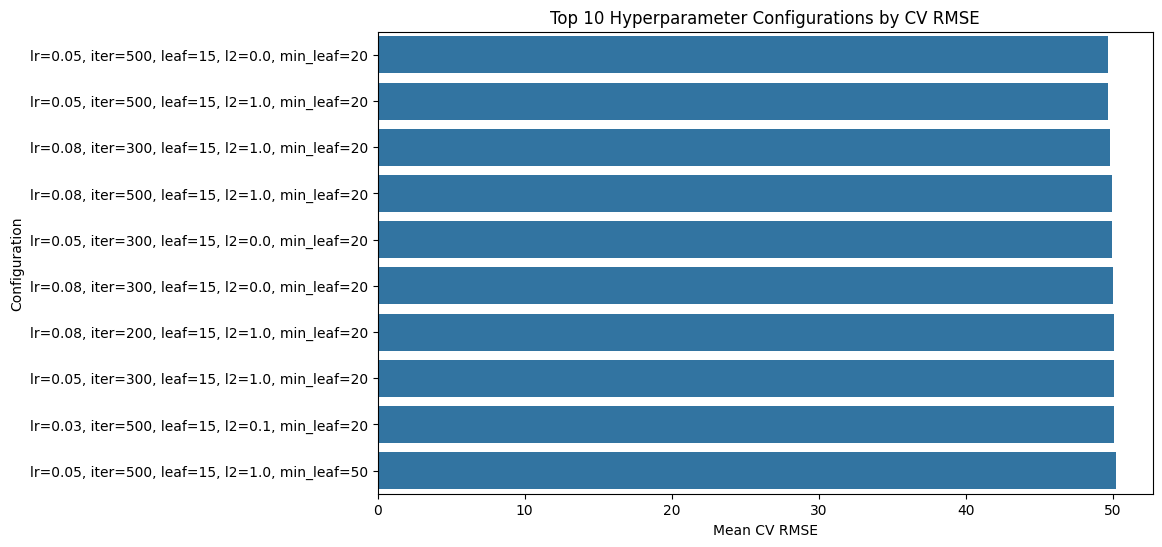

In [56]:
top_tuning_results = tuning_results_df.head(10).copy()

top_tuning_results["config"] = (
    "lr=" + top_tuning_results["param_model__learning_rate"].astype(str)
    + ", iter=" + top_tuning_results["param_model__max_iter"].astype(str)
    + ", leaf=" + top_tuning_results["param_model__max_leaf_nodes"].astype(str)
    + ", l2=" + top_tuning_results["param_model__l2_regularization"].astype(str)
    + ", min_leaf=" + top_tuning_results["param_model__min_samples_leaf"].astype(str)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_tuning_results,
    x="mean_RMSE",
    y="config"
)

plt.title("Top 10 Hyperparameter Configurations by CV RMSE")
plt.xlabel("Mean CV RMSE")
plt.ylabel("Configuration")
plt.show()

### Train Tuned Model

The best model found by grid search is stored as the tuned Hist Gradient Boosting model.

This model has already been refit on the complete training set by `GridSearchCV`.

In [57]:
tuned_hgb_model = grid_search.best_estimator_

tuned_hgb_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['season', 'mnth', 'hr',
                                                   'weekday', 'weathersit',
                                                   'daytime']),
                                                 ('numerical', 'passthrough',
                                                  ['temp', 'atemp', 'hum',
                                                   'windspeed', 'day',
                                                   'dayofyear', 'weekofyear',
                                                   'hr_sin', 'hr_cos',
                                                   'weekday_sin', 'weekday_cos',
                                                   'mnt...
                                                   'cnt_lag_1', 'cnt_lag_2',
                                                   'cnt_lag_24', 'cnt_lag_48',
                                                   'cnt_lag_168',
                                                   'cnt_roll_3_mean',
                                                   'cnt_roll_6_mean',
                                                   'cnt_roll_24_mean',
                                                   'cnt_roll_24_std']),
                                                 ('binary', 'passthrough',
                                                  ['yr', 'holiday',
                                                   'workingday', 'rush_hour',
                                                   'is_weekend'])])),
                ('model',
                 HistGradientBoostingRegressor(early_stopping=False,
                                               learning_rate=0.05, max_iter=500,
                                               max_leaf_nodes=15,
                                               random_state=42))])

### Evaluate Tuned Model on Holdout Test Set

The tuned model is now evaluated on the final holdout test set.

This allows comparison between the original Hist Gradient Boosting model and the tuned version.

In [58]:
y_pred_tuned = tuned_hgb_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2 = r2_score(y_test, y_pred_tuned)

tuned_results = pd.DataFrame({
    "model": ["Tuned Hist Gradient Boosting"],
    "Test_MAE": [tuned_mae],
    "Test_RMSE": [tuned_rmse],
    "Test_R2": [tuned_r2]
})

tuned_results

,model,Test_MAE,Test_RMSE,Test_R2
0,Tuned Hist Gradient Boosting,28.913593,45.471496,0.957214


### Compare Tuned and Untuned Model

The tuned model is compared with the previously evaluated untuned Hist Gradient Boosting model.

In [59]:
hgb_untuned_results = test_results_df[
    test_results_df["model"] == "Hist Gradient Boosting"
].copy()

hgb_comparison_df = pd.concat(
    [hgb_untuned_results, tuned_results],
    ignore_index=True
)

hgb_comparison_df

,model,Test_MAE,Test_RMSE,Test_R2
0,Hist Gradient Boosting,29.219419,47.189135,0.953921
1,Tuned Hist Gradient Boosting,28.913593,45.471496,0.957214


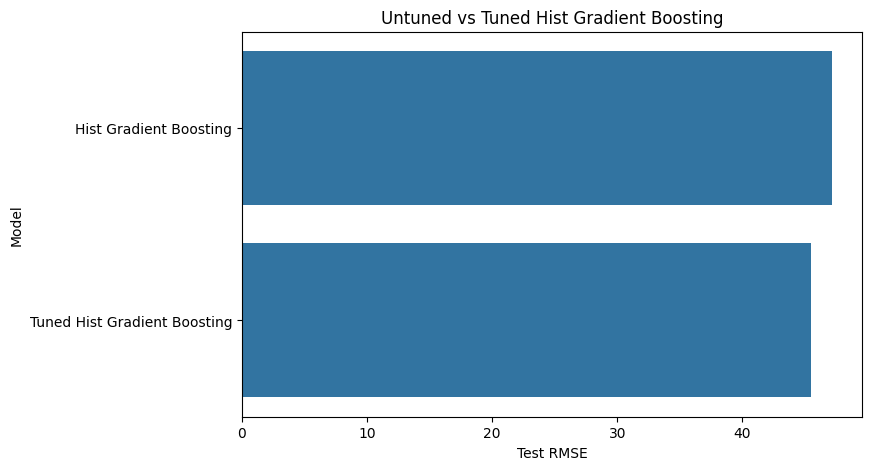

In [60]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=hgb_comparison_df,
    x="Test_RMSE",
    y="model"
)

plt.title("Untuned vs Tuned Hist Gradient Boosting")
plt.xlabel("Test RMSE")
plt.ylabel("Model")
plt.show()

### Interpretation

The hyperparameter tuning improved the performance of the Hist Gradient Boosting model.

Compared to the untuned version, the tuned model achieves:

- a lower MAE: from 29.22 to 28.91
- a lower RMSE: from 47.19 to 45.47
- a higher R²: from 0.954 to 0.957

This indicates that the tuning step slightly improved the model's generalization performance on the holdout test set. The improvement is not dramatic, but it is consistent across all evaluation metrics.

The lower RMSE is especially relevant because RMSE penalizes larger prediction errors more strongly. Therefore, the tuned model appears to handle larger deviations and demand peaks slightly better than the untuned model.

Overall, the tuned Hist Gradient Boosting model is selected as the final model because it achieves the best test performance among the evaluated models.

## Final Model Analysis

After hyperparameter tuning, the tuned Hist Gradient Boosting model achieved the best performance on the holdout test set. Therefore, it is selected as the final model.

In the following section, the final model is analyzed in more detail using prediction errors, actual-vs-predicted values, and feature importance.

In [61]:
final_model = tuned_hgb_model
final_model_name = "Tuned Hist Gradient Boosting"

y_pred_final = final_model.predict(X_test)

final_prediction_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_final,
    "error": y_test.values - y_pred_final,
    "absolute_error": np.abs(y_test.values - y_pred_final)
})

final_prediction_df.head()

,actual,predicted,error,absolute_error
0,381,359.855805,21.144195,21.144195
1,233,275.342453,-42.342453,42.342453
2,136,154.383414,-18.383414,18.383414
3,67,66.509455,0.490545,0.490545
4,28,28.490582,-0.490582,0.490582


### Error Distribution of the Final Model

The distribution of prediction errors is analyzed to check whether the final model systematically overestimates or underestimates demand.

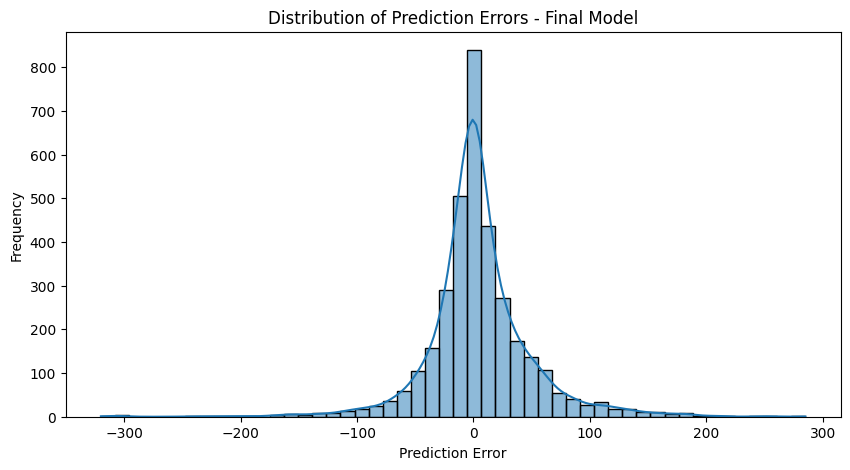

In [62]:
plt.figure(figsize=(10, 5))
sns.histplot(final_prediction_df["error"], bins=50, kde=True)

plt.title("Distribution of Prediction Errors - Final Model")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

### Actual vs Predicted Values

The actual-vs-predicted plot compares the true rental counts with the predictions of the final model.

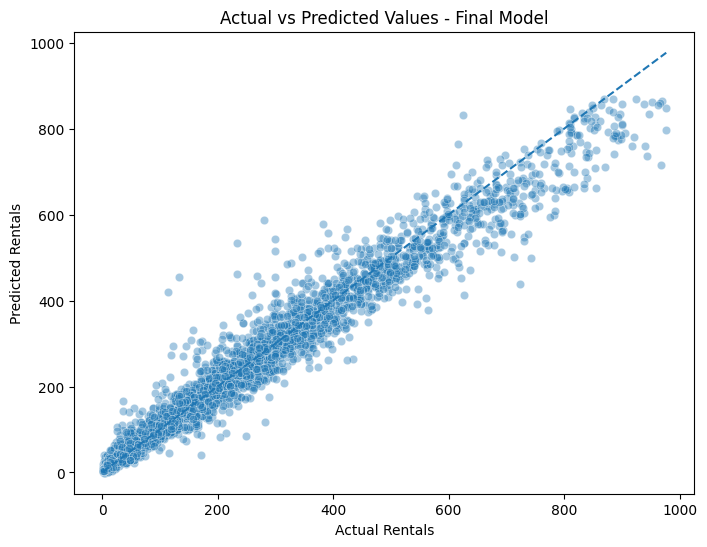

In [63]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=final_prediction_df,
    x="actual",
    y="predicted",
    alpha=0.4
)

plt.plot(
    [final_prediction_df["actual"].min(), final_prediction_df["actual"].max()],
    [final_prediction_df["actual"].min(), final_prediction_df["actual"].max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Values - Final Model")
plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")
plt.show()

### Interpretation

The prediction error distribution of the final model is centered closely around zero. This indicates that the tuned Hist Gradient Boosting model does not show a strong systematic bias toward overprediction or underprediction.

Most prediction errors are relatively small, as the majority of observations are concentrated around zero. This supports the strong overall performance shown by the evaluation metrics.

However, the distribution also contains some larger errors in both directions. Negative errors indicate cases where the model overestimated demand, while positive errors indicate cases where the model underestimated demand.

The tails of the distribution suggest that unusual or extreme demand situations remain more difficult to predict accurately. Overall, the final model performs well, but prediction uncertainty increases for less common demand patterns.

---

The actual-vs-predicted plot shows that the final tuned Hist Gradient Boosting model predicts bike rental demand well overall. Most observations are located close to the diagonal reference line, which represents perfect predictions.

This means that the model captures the general relationship between actual and predicted rental counts: when actual demand increases, the predicted demand also increases.

However, the predictions are not perfect. The spread around the diagonal line represents prediction errors. These deviations become more visible at higher demand levels, where the model sometimes underestimates peak demand. This can be seen in the upper-right area of the plot, where several points lie below the diagonal line.

Overall, the model performs strongly for low and medium demand levels and still performs reasonably well for high demand values. Nevertheless, extreme demand peaks remain more difficult to predict accurately.



### Permutation Importance

After selecting the tuned Hist Gradient Boosting model as the final model, permutation importance is used to identify the most relevant features for prediction.

Permutation importance measures how strongly model performance decreases when a feature is randomly shuffled. Features that cause a strong decrease in performance are considered more important.

In [64]:
from sklearn.inspection import permutation_importance

final_perm_importance = permutation_importance(
    estimator=final_model,
    X=X_test,
    y=y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

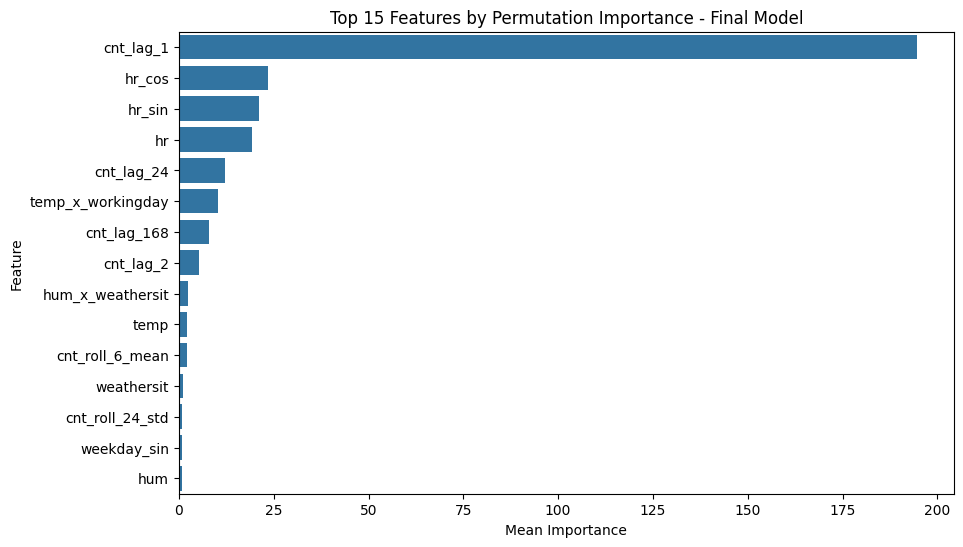

In [65]:
final_perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": final_perm_importance.importances_mean,
    "importance_std": final_perm_importance.importances_std
})

final_perm_importance_df = final_perm_importance_df.sort_values(
    by="importance_mean",
    ascending=False
)

final_perm_importance_df.head(20)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_perm_importance_df.head(15),
    x="importance_mean",
    y="feature"
)

plt.title("Top 15 Features by Permutation Importance - Final Model")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.show()

### Interpretation

The permutation importance results of the final tuned model show that `cnt_lag_1` is by far the most influential feature. This means that the rental demand of the previous hour is the strongest predictor for the current demand. The model therefore relies heavily on short-term temporal dependency.

Time-related features are also highly relevant. The features `hr_cos`, `hr_sin`, and `hr` show that the hour of the day is a major driver of rental demand. This supports the patterns identified during the EDA, especially the strong daily structure and commuting-related peaks.

Additional lag features such as `cnt_lag_24`, `cnt_lag_168`, and `cnt_lag_2` also contribute to the prediction. This indicates that demand follows not only short-term patterns, but also daily and weekly recurring structures.

The interaction feature `temp_x_workingday` is among the more important variables as well. This suggests that the effect of temperature differs depending on whether the observation belongs to a working day. This is consistent with the earlier finding that working days and non-working days show different demand patterns.

Weather-related variables such as `hum_x_weathersit`, `temp`, `weathersit`, and `hum` appear in the top features, but their importance is clearly lower than the lag-based and time-based variables. This indicates that weather conditions provide additional predictive information, but the strongest signal comes from recent demand and temporal structure.

Overall, the feature importance analysis confirms that the final model mainly predicts bike rental demand based on recent usage, daily patterns, and recurring temporal behavior. Weather-related information improves the prediction, but plays a secondary role compared to lag and time features.